In [1]:
"""
Script d'entraînement LoRA pour générer des personnages Simpsons
Exécuter : python train.py
"""

import os
import shutil
import json
import requests
import kagglehub

# ===== CONFIGURATION =====
BASE_MODEL_ID = "runwayml/stable-diffusion-v1-5"
OUTPUT_DIR = "/tf/workspace/diffusion/simpsons_lora_results"
TRAIN_DATA_DIR = "./train_data"
DATASET_NAME = "kostastokis/simpsons-faces"

def setup_environment():
    """Installation des dépendances nécessaires"""
    print("📥 [1/3] Installation des dépendances...")
    os.system("pip install -q accelerate transformers diffusers peft bitsandbytes xformers datasets kagglehub pillow")

    # Téléchargement du script officiel HuggingFace
    if not os.path.exists("train_text_to_image_lora.py"):
        print("📥 Téléchargement du script d'entraînement...")
        url = "https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py"
        r = requests.get(url)
        with open("train_text_to_image_lora.py", "wb") as f:
            f.write(r.content)

    print("✅ Environnement prêt\n")

def prepare_dataset():
    """Téléchargement et préparation du dataset Simpsons"""
    print(f"📂 [2/3] Préparation du dataset '{DATASET_NAME}'...")

    # Téléchargement via Kaggle
    path = kagglehub.dataset_download(DATASET_NAME)
    source = os.path.join(path, "cropped") if os.path.exists(os.path.join(path, "cropped")) else path

    # Nettoyage du dossier
    if os.path.exists(TRAIN_DATA_DIR):
        shutil.rmtree(TRAIN_DATA_DIR)
    os.makedirs(TRAIN_DATA_DIR)

    # Récupération des images
    valid_extensions = ('.png', '.jpg', '.jpeg')
    images = [f for f in os.listdir(source) if f.lower().endswith(valid_extensions)]
    print(f"   📸 {len(images)} images trouvées")

    # ===== PROMPTS VARIÉS POUR MEILLEUR APPRENTISSAGE =====
    prompts = [
        "a simpson character, yellow skin, cartoon style",
        "portrait of a simpson character with yellow skin",
        "simpson animated character, bright colors",
        "face of a simpsons tv show character",
        "cartoon simpson character portrait"
    ]

    # Création du fichier metadata.jsonl
    metadata_path = os.path.join(TRAIN_DATA_DIR, "metadata.jsonl")
    with open(metadata_path, 'w') as f:
        for i, img in enumerate(images):
            # Copie de l'image
            shutil.copy(os.path.join(source, img), os.path.join(TRAIN_DATA_DIR, img))
            # Variation des prompts
            prompt = prompts[i % len(prompts)]
            f.write(json.dumps({"file_name": img, "text": prompt}) + "\n")

    print(f"✅ Dataset prêt dans {TRAIN_DATA_DIR}\n")

def start_training():
    """Lancement de l'entraînement LoRA"""
    print("🚀 [3/3] Lancement de l'entraînement LoRA...")
    print("⏱️  Cela peut prendre 30-60 minutes sur GPU (plusieurs heures sur CPU)\n")

    # ===== COMMANDE D'ENTRAÎNEMENT OPTIMISÉE =====
    cmd = f"""
    accelerate launch train_text_to_image_lora.py \
      --pretrained_model_name_or_path="{BASE_MODEL_ID}" \
      --train_data_dir="{TRAIN_DATA_DIR}" \
      --dataset_name="imagefolder" \
      --caption_column="text" \
      --resolution=512 \
      --center_crop \
      --random_flip \
      --train_batch_size=2 \
      --gradient_accumulation_steps=4 \
      --max_train_steps=3000 \
      --learning_rate=5e-05 \
      --lr_scheduler="cosine_with_restarts" \
      --lr_warmup_steps=200 \
      --output_dir="{OUTPUT_DIR}" \
      --mixed_precision="fp16" \
      --checkpointing_steps=500 \
      --validation_prompt="a simpson character with yellow skin" \
      --validation_epochs=1 \
      --seed=42
    """

    exit_code = os.system(cmd)

    if exit_code == 0:
        print(f"\n🎉 ✅ ENTRAÎNEMENT TERMINÉ !")
        print(f"📁 Modèle sauvegardé dans : {OUTPUT_DIR}")
        print(f"🚀 Vous pouvez maintenant lancer : python generate.py")
    else:
        print(f"\n❌ Erreur lors de l'entraînement (code {exit_code})")

if __name__ == "__main__":
    setup_environment()
    prepare_dataset()
    start_training()

📥 [1/3] Installation des dépendances...


✅ Environnement prêt

📂 [2/3] Préparation du dataset 'kostastokis/simpsons-faces'...
   📸 9877 images trouvées
✅ Dataset prêt dans ./train_data

🚀 [3/3] Lancement de l'entraînement LoRA...
⏱️  Cela peut prendre 30-60 minutes sur GPU (plusieurs heures sur CPU)



The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-01-25 20:17:22.613322: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 20:17:23.162886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compile


🎉 ✅ ENTRAÎNEMENT TERMINÉ !
📁 Modèle sauvegardé dans : /tf/workspace/diffusion/simpsons_lora_results
🚀 Vous pouvez maintenant lancer : python generate.py


In [2]:
"""
Script de génération de personnages Simpsons
Exécuter : python generate.py
"""

import os
import torch
from datetime import datetime
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# ===== CONFIGURATION =====
LORA_PATH = "/tf/workspace/diffusion/simpsons_lora_results"
BASE_MODEL_ID = "runwayml/stable-diffusion-v1-5"
OUTPUT_FOLDER = "/tf/workspace/diffusion/generated_simpsons"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Création du dossier de sortie
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def load_pipeline():
    """Chargement du modèle avec le LoRA entraîné"""
    print(f"🧠 Chargement du modèle {BASE_MODEL_ID}...")

    try:
        # Chargement du modèle de base
        pipe = StableDiffusionPipeline.from_pretrained(
            BASE_MODEL_ID,
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            safety_checker=None
        ).to(DEVICE)

        # Scheduler optimisé
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    except Exception as e:
        print(f"❌ Erreur lors du chargement du modèle : {e}")
        return None

    # Vérification de l'existence du LoRA
    lora_weights = os.path.join(LORA_PATH, "pytorch_lora_weights.safetensors")
    if not os.path.exists(lora_weights):
        print(f"❌ LoRA introuvable : {lora_weights}")
        print(f"   Assurez-vous d'avoir lancé 'python train.py' d'abord !")
        return None

    # Chargement du LoRA
    print("🔌 Chargement du LoRA Simpsons...")
    try:
        pipe.load_lora_weights(LORA_PATH, weight_name="pytorch_lora_weights.safetensors")
    except Exception as e:
        print(f"❌ Erreur lors du chargement du LoRA : {e}")
        return None

    print("✅ Pipeline prête !\n")
    return pipe

def generate_character(pipe, character_name):
    """Génère une image d'un personnage"""

    # ===== PROMPT OPTIMISÉ =====
    prompt = f"{character_name} as a simpson character, yellow skin, cartoon style, high quality, detailed"

    negative_prompt = (
        "realistic, photograph, photo, 3d render, ugly, deformed, "
        "blurry, low quality, distorted, bad anatomy, extra limbs"
    )

    print(f"🎨 Génération de '{character_name}'...")

    try:
        # Génération de l'image
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            guidance_scale=7.5,
            height=512,
            width=512,
            cross_attention_kwargs={"scale": 1.0}  # Force maximale du LoRA
        ).images[0]

        # Sauvegarde
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{character_name.split()[0].lower()}_{timestamp}.png"
        filepath = os.path.join(OUTPUT_FOLDER, filename)
        image.save(filepath)

        print(f"✅ Sauvegardé : {filepath}\n")
        return True

    except Exception as e:
        print(f"❌ Erreur lors de la génération : {e}\n")
        return False

def interactive_mode(pipe):
    """Mode interactif pour générer plusieurs personnages"""
    print("=" * 60)
    print("🎨 GÉNÉRATEUR DE PERSONNAGES SIMPSONS")
    print("=" * 60)
    print("Exemples : Homer Simpson, Marge, Bart, Lisa, Moe, Barney...")
    print("Tapez 'q' pour quitter")
    print("=" * 60)
    print()

    while True:
        character = input("👤 Personnage à générer : ").strip()

        if character.lower() == 'q':
            print("👋 Au revoir !")
            break

        if not character:
            continue

        generate_character(pipe, character)

if __name__ == "__main__":
    if DEVICE == "cpu":
        print("⚠️  ATTENTION : CPU détecté - La génération sera TRÈS lente\n")

    pipeline = load_pipeline()

    if pipeline:
        interactive_mode(pipeline)

2026-02-05 21:30:27.334135: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 21:30:27.907489: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.11/dist

🧠 Chargement du modèle runwayml/stable-diffusion-v1-5...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


🔌 Chargement du LoRA Simpsons...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ Pipeline prête !

🎨 GÉNÉRATEUR DE PERSONNAGES SIMPSONS
Exemples : Homer Simpson, Marge, Bart, Lisa, Moe, Barney...
Tapez 'q' pour quitter

🎨 Génération de 'raw photo of Homer Simpson, sks simpson style, stubble beard texture, looking at camera, tired eyes, office fluorescent lighting, hyper realistic, 8k, highly detailed skin pores, shot on Canon 5D'...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Sauvegardé : /tf/workspace/diffusion/generated_simpsons/raw_20260205_213150.png



KeyboardInterrupt: Interrupted by user

👀 Affichage de 14 images



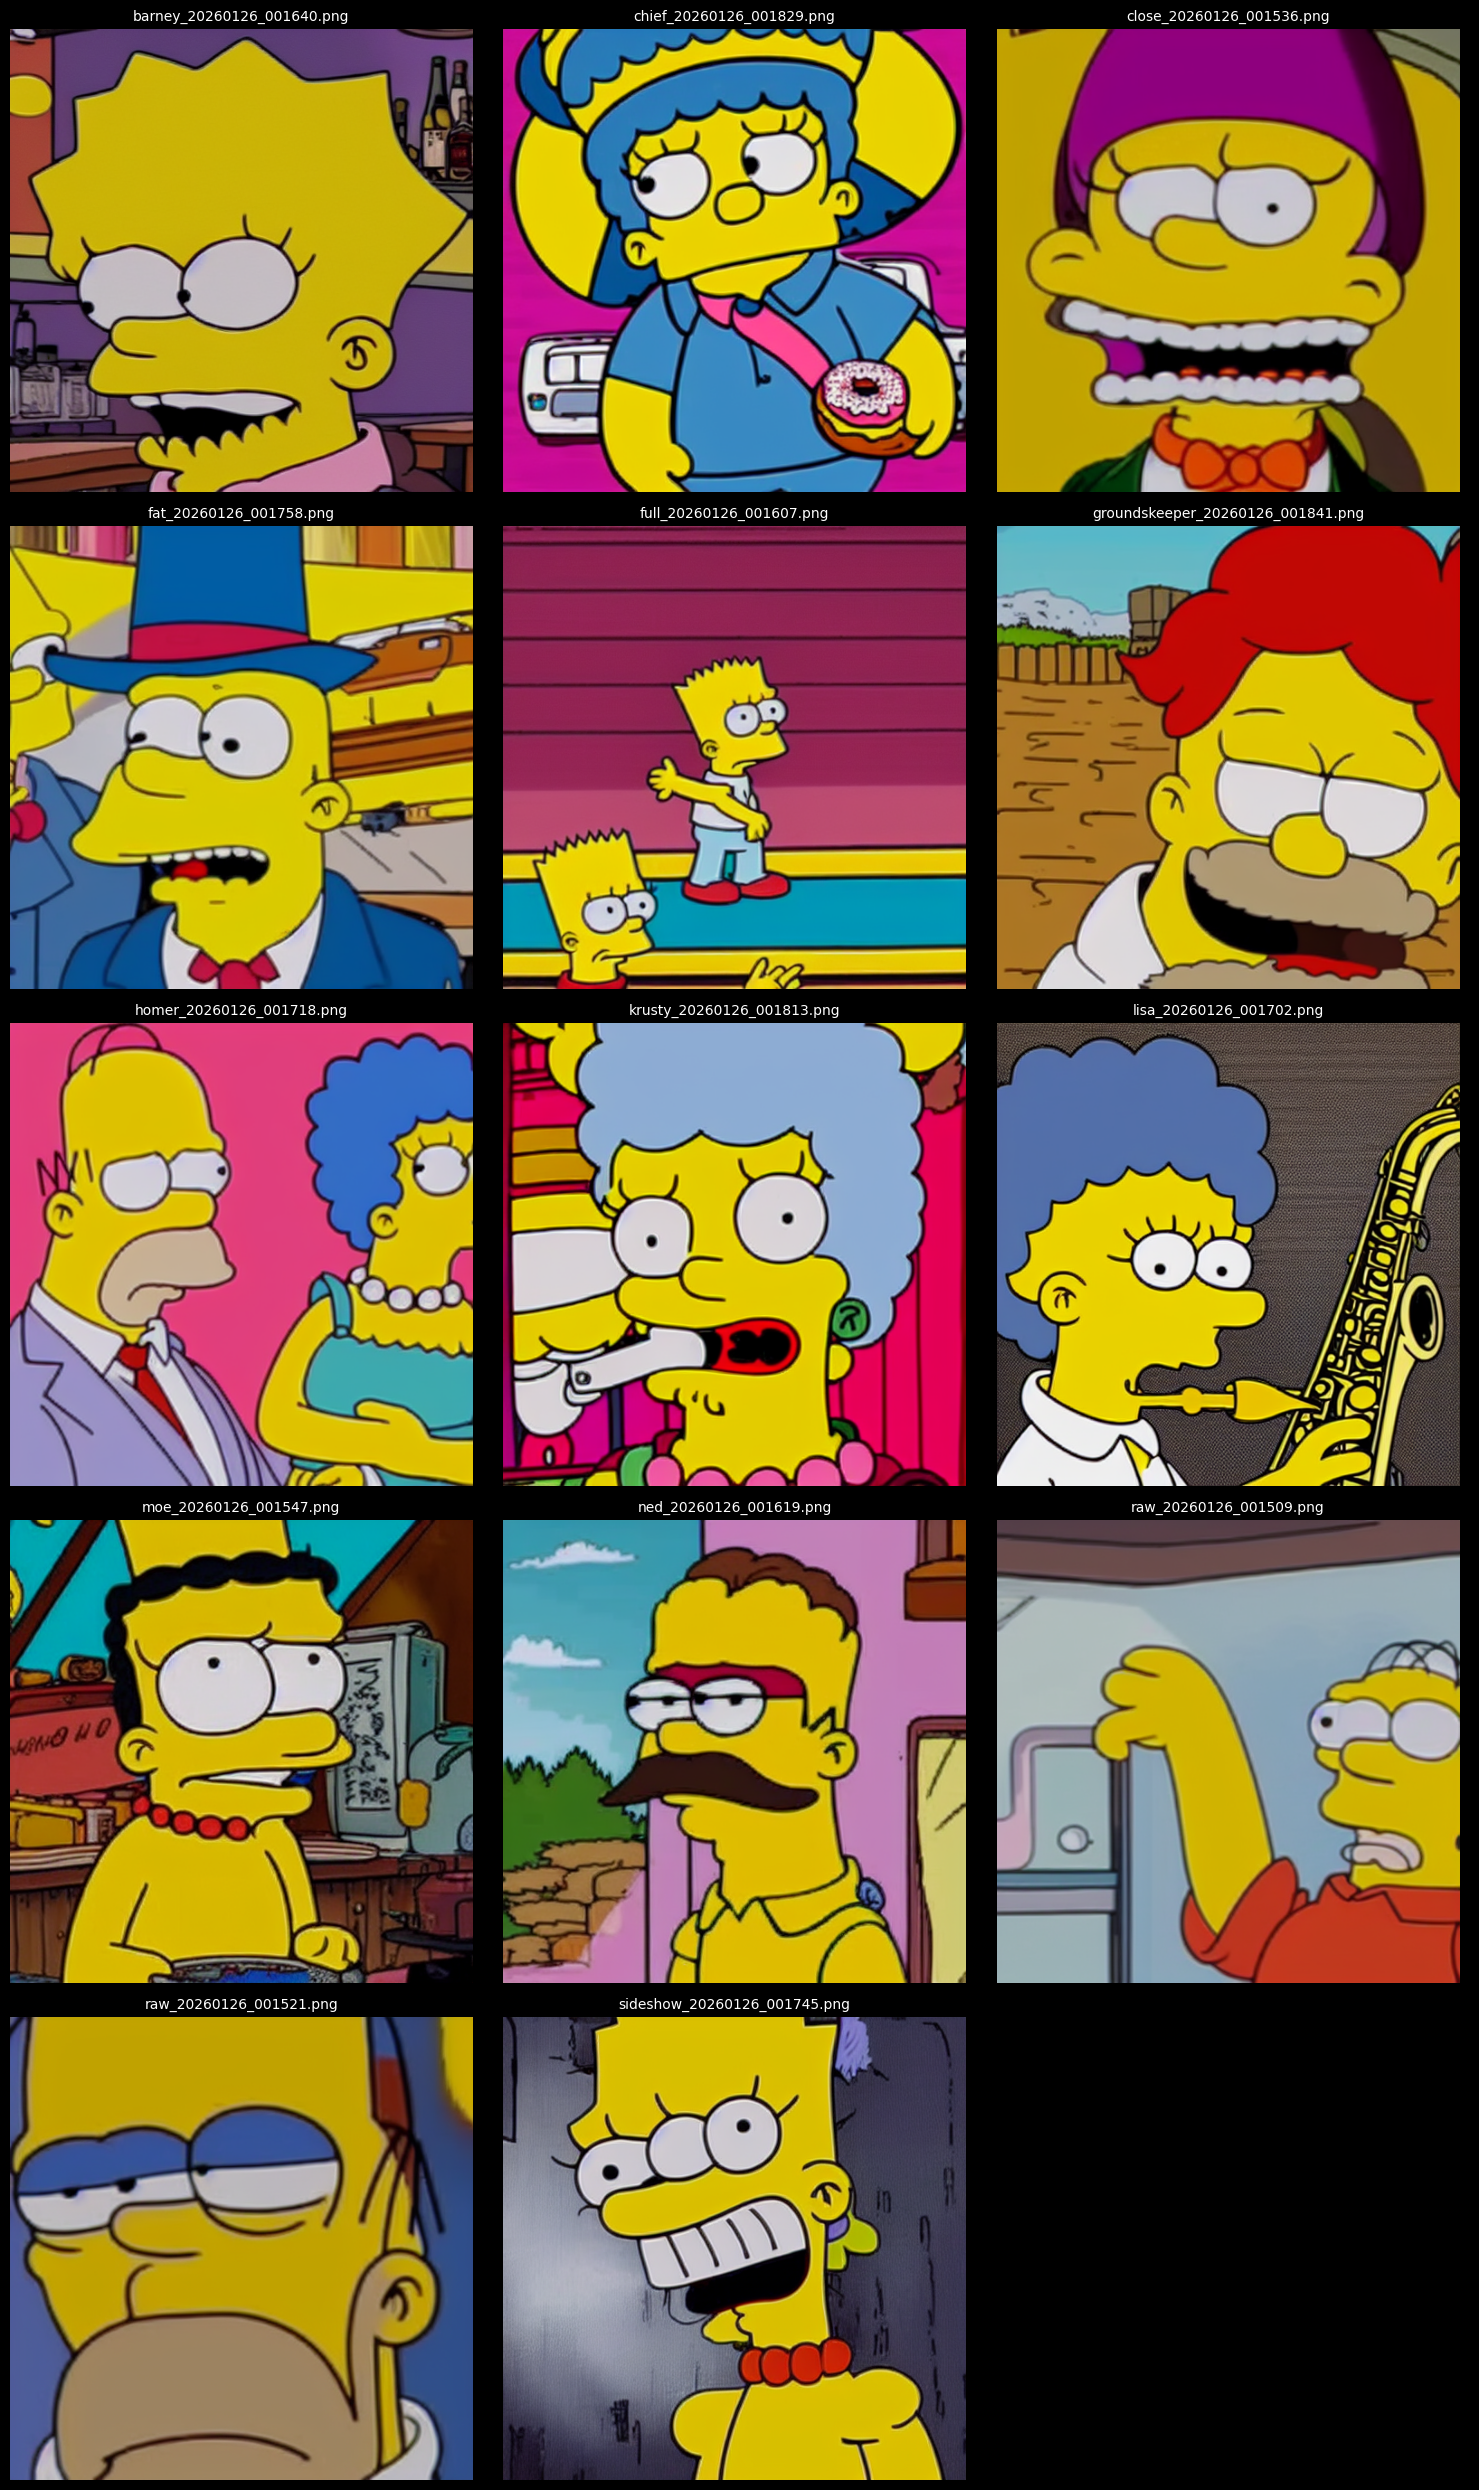

In [1]:
"""
Script pour visualiser les images générées
Exécuter : python view_results.py
"""

import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

OUTPUT_FOLDER = "/tf/workspace/diffusion/generated_simpsons"

def display_images():
    """Affiche toutes les images générées en grille"""
    images = sorted(glob.glob(os.path.join(OUTPUT_FOLDER, "*.png")))

    if not images:
        print("❌ Aucune image trouvée dans le dossier.")
        print(f"   Générez-en d'abord avec : python generate.py")
        return

    print(f"👀 Affichage de {len(images)} images\n")

    # Configuration de la grille
    cols = 3
    rows = (len(images) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

    # Flatten axes pour itération facile
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Affichage des images
    for idx, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(img_path), fontsize=10)
        axes[idx].axis('off')

    # Cacher les axes vides
    for idx in range(len(images), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    display_images()

In [12]:
ls -lh "/tf/workspace/diffusion/simpsons_lora_result/pytorch_lora_weights.safetensors"

ls: cannot access '/tf/workspace/diffusion/simpsons_lora_result/pytorch_lora_weights.safetensors': No such file or directory
